In [1]:
import json
import re
from pathlib import Path

input_path = Path(
    r"F:\ERP_data\final_corpusRCRS_clean.jsonl")
output_path = Path(
    r"F:\ERP_data\RQ3_career_extracted.jsonl")

# Career keywords
J = re.compile(
    r"\b(career|job|jobs|hiring|hire|interview|salary|pay|wage|"
    r"promotion|workplace|employment|internship|intern|"
    r"industry|profession)\b",
    re.I
)

# Extract career subset
total = 0
valid_text = 0
career_count = 0

with input_path.open("r", encoding="utf-8") as fin, \
     output_path.open("w", encoding="utf-8") as fout:

    for line in fin:

        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue

        total += 1

        # Prefer final analysis text
        text = obj.get("text_for_analysis", "")

        if not isinstance(text, str) or not text.strip():

            if isinstance(obj.get("body"), str):
                text = obj.get("body", "")

            elif isinstance(obj.get("selftext"), str):
                text = obj.get("selftext", "")

            else:
                text = ""

        text = text.strip()

        if not text:
            continue

        valid_text += 1

        # Career extraction
        if not J.search(text):
            continue

        career_count += 1

        fout.write(
            json.dumps(
                obj,
                ensure_ascii=False
            ) + "\n"
        )

# 4. Results
print("=" * 55)
print("RQ3 Career extraction completed")
print("=" * 55)
print(f"Total rows:          {total:,}")
print(f"Valid texts:         {valid_text:,}")
print(f"Career extracted:    {career_count:,}")

if valid_text > 0:
    print(
        f"Career proportion:   "
        f"{career_count / valid_text:.2%}"
    )

print("\nSaved to:")
print(output_path)

RQ2 Career extraction completed
Total rows:          2,404
Valid texts:         2,404
Career extracted:    732
Career proportion:   30.45%

Saved to:
F:\ERP_data\RQ2_career_extracted.jsonl


In [1]:
# 100 sample
import json
import pandas as pd
import random
from pathlib import Path

input_path = Path(
    r"F:\ERP_data\RQ3_career_extracted.jsonl"
)
output_path = Path(
    r"F:\ERP_data\RQ3_career_sample_100.xlsx"
)

# Read all career candidates
records = []
with input_path.open("r", encoding="utf-8") as f:
    for line in f:
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue
        records.append(obj)
        
print(f"Total career candidates: {len(records):,}")

#  Random sample 100
random.seed(42)
sample = random.sample(
    records,
    k=min(100, len(records))
)
print(f"Sampled: {len(sample)}")

# Convert to DataFrame
df_sample = pd.DataFrame(sample)

#  Select useful columns
preferred_cols = [
    "id",
    "type",
    "subreddit",
    "text_for_analysis",
    "body",
    "title",
    "selftext"
]

existing_cols = [
    col for col in preferred_cols
    if col in df_sample.columns
]

df_sample = df_sample[existing_cols].copy()

#  Add manual annotation columns
df_sample.insert(0, "sample_id", range(1, len(df_sample) + 1))
df_sample["relevant"] = ""
df_sample["reason"] = ""

# Export Excel
df_sample.to_excel(
    output_path,
    index=False
)

print("\nSaved to:")
print(output_path)

Total career candidates: 732
Sampled: 100

Saved to:
F:\ERP_data\RQ3_career_sample_100.xlsx


In [4]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to D:\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to D:\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to D:\nltk_data...


True

In [5]:
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [17]:
# 1. Keyword Frequency Analysis
   # text pre-processing
custom_stopwords = {
    "would", "could", "also", "one",
    "get", "got", "like", "think",
    "know", "really", "much", "even",
    "people", "thing", "things",
    "say", "said", "make", "way",

    # the second round
    "want", "less", "many", "see",
    "time", "still", "need", "year",
    "lot", "actually", "point", "take",
    "well", "good", "likely",
    "different", "going", "fact"
}

stop_words.update(custom_stopwords)

In [24]:
additional_stopwords_2 = {
    "right",
    "look",
    "getting",
    "reason",
    "etc",
    "mean",
    "something",
    "year"
}

stop_words.update(additional_stopwords_2)

In [18]:
    # Concept normalization
    # single-plural

normalization = {

    # Gender
    "women": "woman",
    "men": "man",
    "girls": "girl",
    "boys": "boy",

    # Career
    "jobs": "job",
    "careers": "career",

    # STEM / education
    "engineers": "engineer",
    "sciences": "science",
    "students": "student"
}

In [19]:
def preprocess(text):

    if not isinstance(text, str):
        return []

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # keep alphabetic words
    tokens = re.findall(r"\b[a-z]+\b", text)

    # remove stopwords + very short tokens
    tokens = [
        token
        for token in tokens
        if token not in stop_words
        and len(token) > 2
    ]

    # lemmatization
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]

    # Concept normalization
    tokens = [
        normalization.get(token, token)
        for token in tokens
    ]
    
    return tokens

In [25]:
df["tokens"] = df["text_for_analysis"].apply(preprocess)

print(df[["text_for_analysis", "tokens"]].head())

                                   text_for_analysis  \
0  What are you talking about? Professors get pai...   
1  Bitch I went from a U to a grade 5 in a month ...   
2  She’s holding the danger end of a soldering ir...   
3  That is not why women usually work in lower pa...   
4  &gt;Maybe women shouldn't have to register too...   

                                              tokens  
0  [talking, professor, paid, teacher, sure, live...  
1  [bitch, went, grade, month, gcse, silly, mum, ...  
2  [holding, danger, end, soldering, iron, profes...  
3  [woman, usually, work, lower, paying, career, ...  
4  [maybe, woman, register, gender, discrepancy, ...  


In [26]:
empty_count = (df["tokens"].str.len() == 0).sum()

print("Empty after preprocessing:", empty_count)

Empty after preprocessing: 0


In [27]:
  # word freq
all_tokens = [
    token
    for tokens in df["tokens"]
    for token in tokens
]

word_freq = Counter(all_tokens)

freq_df = pd.DataFrame(
    word_freq.most_common(),
    columns=["word", "frequency"]
)

print("\n===== Top 50 Keywords =====")

print(
    freq_df.head(50).to_string(index=False)
)


===== Top 50 Keywords =====
       word  frequency
      woman       3521
        man       1913
       stem       1064
        job        876
      field        765
     female        560
       work        522
       male        493
     gender        434
     career        351
engineering        309
       girl        260
    science        255
    society        208
        pay        192
    problem        180
        gap        178
     social        172
    program        171
     school        169
     better        169
      study        162
  dominated        159
     higher        156
    country        154
    company        153
   feminist        148
       role        148
    student        147
   engineer        146
        boy        146
   industry        145
      equal        140
       high        139
   equality        138
      issue        135
       year        134
   computer        133
    working        133
 interested        132
     choose        130
     

In [28]:
  # document freq
document_freq = Counter()

for tokens in df["tokens"]:
    document_freq.update(set(tokens))


doc_freq_df = pd.DataFrame(
    document_freq.items(),
    columns=["word", "document_frequency"]
)


freq_df = freq_df.merge(
    doc_freq_df,
    on="word",
    how="left"
)


freq_df["document_percentage"] = (
    freq_df["document_frequency"]
    / len(df)
    * 100
)


print("\n===== Top 50 after refinement =====")

print(
    freq_df.head(50)[
        [
            "word",
            "frequency",
            "document_frequency",
            "document_percentage"
        ]
    ].to_string(
        index=False,
        formatters={
            "document_percentage": "{:.2f}%".format
        }
    )
)


===== Top 50 after refinement =====
       word  frequency  document_frequency document_percentage
      woman       3521                 683              93.43%
        man       1913                 483              66.07%
       stem       1064                 524              71.68%
        job        876                 447              61.15%
      field        765                 386              52.80%
     female        560                 262              35.84%
       work        522                 260              35.57%
       male        493                 264              36.11%
     gender        434                 237              32.42%
     career        351                 217              29.69%
engineering        309                 177              24.21%
       girl        260                 139              19.02%
    science        255                 132              18.06%
    society        208                 123              16.83%
        pay       

In [29]:
# 2. Concept-based co-occurrence analysis
    #set up Concept Dictionary
concept_groups = {

    "gender": {
        "woman", "man", "female", "male",
        "girl", "boy", "gender"
    },

    "career": {
        "job", "work", "career",
        "pay", "salary", "wage",
        "hiring", "hire",
        "promotion", "workplace",
        "employment", "internship",
        "intern", "industry", "profession",
        "company"
    },

    "stem": {
        "stem",
        "engineering", "engineer",
        "science",
        "computer",
        "programming",
        "technology",
        "math", "maths", "mathematics",
        "physics", "biology",
        "data"
    },

    "inequality": {
        "bias",
        "discrimination",
        "sexism",
        "sexist",
        "gap",
        "dominated",
        "underrepresented",
        "equal",
        "equality"
    },

    "education": {
        "school",
        "student",
        "study",
        "degree",
        "university",
        "college"
    }
}

In [ ]:
    # Detect concepts in each document
from collections import Counter
import pandas as pd
from itertools import combinations

In [33]:
def get_concepts(tokens):
    token_set = set(tokens)
    return {
        term
        for terms in concept_groups.values()
        for term in terms
        if term in token_set
    }

df["concepts"] = df["tokens"].apply(get_concepts)

print(
    df[
        ["text_for_analysis", "concepts"]
    ].head(10)
)

                                   text_for_analysis  \
0  What are you talking about? Professors get pai...   
1  Bitch I went from a U to a grade 5 in a month ...   
2  She’s holding the danger end of a soldering ir...   
3  That is not why women usually work in lower pa...   
4  &gt;Maybe women shouldn't have to register too...   
5  I actually had an opportunity to go back and d...   
6  No such conclusions have been made by any scie...   
7  &gt; Here in Chicago, I’ve been paying $1600/m...   
8  [According to the Department of Education](htt...   
9  since when was engineering \[or any job\] a "b...   

                                            concepts  
0  {female, dominated, equal, work, industry, man...  
1  {engineering, degree, work, science, man, woma...  
2                          {profession, stem, woman}  
3  {engineering, work, career, man, engineer, wom...  
4  {man, equality, woman, wage, stem, gap, gender...  
5                 {school, female, woman, stem, job} 

In [37]:
from collections import Counter
from itertools import combinations
import pandas as pd

pair_counts = Counter()

for concepts in df["concepts"]:
    concepts = sorted(concepts)

    for pair in combinations(concepts, 2):
        pair_counts[pair] += 1


pair_df = pd.DataFrame(
    [
        {
            "concept_1": pair[0],
            "concept_2": pair[1],
            "cooccurrence": count
        }
        for pair, count in pair_counts.items()
    ]
)

pair_df = pair_df.sort_values(
    "cooccurrence",
    ascending=False
).reset_index(drop=True)

pair_df["document_percentage"] = (
    pair_df["cooccurrence"]
    / len(df)
    * 100
)

print("\n===== Top 50 Co-occurring Pairs =====")

print(
    pair_df.head(50).to_string(
        index=False,
        formatters={
            "document_percentage": "{:.2f}%".format
        }
    )
)


===== Top 50 Co-occurring Pairs =====
  concept_1 concept_2  cooccurrence document_percentage
       stem     woman           494              67.58%
        man     woman           471              64.43%
        job     woman           420              57.46%
        man      stem           329              45.01%
        job      stem           316              43.23%
        job       man           314              42.95%
      woman      work           249              34.06%
       male     woman           246              33.65%
     female     woman           233              31.87%
     gender     woman           225              30.78%
       male       man           213              29.14%
     career     woman           209              28.59%
        man      work           201              27.50%
     female       man           188              25.72%
       male      stem           183              25.03%
        job      work           180              24.62%
     gend

In [38]:
# =========================================================
# Map each concept to its category
# =========================================================

concept_to_group = {}

for group, terms in concept_groups.items():
    for term in terms:
        concept_to_group[term] = group


pair_df["group_1"] = pair_df["concept_1"].map(concept_to_group)
pair_df["group_2"] = pair_df["concept_2"].map(concept_to_group)

print(
    pair_df[
        [
            "concept_1",
            "concept_2",
            "group_1",
            "group_2",
            "cooccurrence"
        ]
    ].head(20)
)

   concept_1 concept_2 group_1 group_2  cooccurrence
0       stem     woman    stem  gender           494
1        man     woman  gender  gender           471
2        job     woman  career  gender           420
3        man      stem  gender    stem           329
4        job      stem  career    stem           316
5        job       man  career  gender           314
6      woman      work  gender  career           249
7       male     woman  gender  gender           246
8     female     woman  gender  gender           233
9     gender     woman  gender  gender           225
10      male       man  gender  gender           213
11    career     woman  career  gender           209
12       man      work  gender  career           201
13    female       man  gender  gender           188
14      male      stem  gender    stem           183
15       job      work  career  career           180
16    gender       man  gender  gender           178
17    gender      stem  gender    stem        

In [39]:
# =========================================================
# Keep analytically useful cross-group relationships
# =========================================================

target_group_pairs = {
    frozenset(["gender", "career"]),
    frozenset(["gender", "inequality"]),
    frozenset(["career", "inequality"]),
    frozenset(["career", "stem"])
}


def keep_pair(row):

    pair_type = frozenset([
        row["group_1"],
        row["group_2"]
    ])

    return pair_type in target_group_pairs


focused_pairs = pair_df[
    pair_df.apply(keep_pair, axis=1)
].copy()


focused_pairs = focused_pairs.sort_values(
    "cooccurrence",
    ascending=False
).reset_index(drop=True)


print("\n===== Focused Co-occurrence Pairs =====")

print(
    focused_pairs.head(50).to_string(
        index=False,
        formatters={
            "document_percentage": "{:.2f}%".format
        }
    )
)


===== Focused Co-occurrence Pairs =====
  concept_1   concept_2  cooccurrence document_percentage    group_1    group_2
        job       woman           420              57.46%     career     gender
        job        stem           316              43.23%     career       stem
        job         man           314              42.95%     career     gender
      woman        work           249              34.06%     gender     career
     career       woman           209              28.59%     career     gender
        man        work           201              27.50%     gender     career
     career        stem           171              23.39%     career       stem
     female         job           171              23.39%     gender     career
       stem        work           168              22.98%       stem     career
        job        male           164              22.44%     career     gender
     career         man           149              20.38%     career     gender

In [40]:
# =========================================================
# Document frequency for each concept
# =========================================================

concept_doc_freq = Counter()

for concepts in df["concepts"]:
    for concept in concepts:
        concept_doc_freq[concept] += 1

In [41]:
# =========================================================
# Calculate Jaccard similarity
# =========================================================

def calculate_jaccard(row):

    a = row["concept_1"]
    b = row["concept_2"]

    freq_a = concept_doc_freq[a]
    freq_b = concept_doc_freq[b]

    intersection = row["cooccurrence"]

    union = (
        freq_a
        + freq_b
        - intersection
    )

    if union == 0:
        return 0

    return intersection / union


focused_pairs["jaccard"] = focused_pairs.apply(
    calculate_jaccard,
    axis=1
)

In [42]:
focused_pairs["concept_1_df"] = (
    focused_pairs["concept_1"]
    .map(concept_doc_freq)
)

focused_pairs["concept_2_df"] = (
    focused_pairs["concept_2"]
    .map(concept_doc_freq)
)

In [43]:
focused_stable = focused_pairs[
    focused_pairs["cooccurrence"] >= 10
].copy()

In [44]:
print("\n===== Top pairs by Co-occurrence =====")

print(
    focused_stable[
        [
            "concept_1",
            "concept_2",
            "group_1",
            "group_2",
            "cooccurrence",
            "document_percentage",
            "jaccard"
        ]
    ]
    .sort_values(
        "cooccurrence",
        ascending=False
    )
    .head(30)
    .to_string(
        index=False,
        formatters={
            "document_percentage": "{:.2f}%".format,
            "jaccard": "{:.3f}".format
        }
    )
)


===== Top pairs by Co-occurrence =====
  concept_1 concept_2    group_1 group_2  cooccurrence document_percentage jaccard
        job     woman     career  gender           420              57.46%   0.592
        job      stem     career    stem           316              43.23%   0.482
        job       man     career  gender           314              42.95%   0.510
      woman      work     gender  career           249              34.06%   0.359
     career     woman     career  gender           209              28.59%   0.302
        man      work     gender  career           201              27.50%   0.371
     career      stem     career    stem           171              23.39%   0.300
     female       job     gender  career           171              23.39%   0.318
       stem      work       stem  career           168              22.98%   0.273
        job      male     career  gender           164              22.44%   0.300
     career       man     career  gender       

In [45]:
print("\n===== Top pairs by Jaccard =====")

print(
    focused_stable[
        [
            "concept_1",
            "concept_2",
            "group_1",
            "group_2",
            "cooccurrence",
            "document_percentage",
            "jaccard"
        ]
    ]
    .sort_values(
        "jaccard",
        ascending=False
    )
    .head(30)
    .to_string(
        index=False,
        formatters={
            "document_percentage": "{:.2f}%".format,
            "jaccard": "{:.3f}".format
        }
    )
)


===== Top pairs by Jaccard =====
  concept_1 concept_2    group_1 group_2  cooccurrence document_percentage jaccard
        job     woman     career  gender           420              57.46%   0.592
        job       man     career  gender           314              42.95%   0.510
        job      stem     career    stem           316              43.23%   0.482
        gap      wage inequality  career            52               7.11%   0.400
        man      work     gender  career           201              27.50%   0.371
      woman      work     gender  career           249              34.06%   0.359
  dominated      male inequality  gender            93              12.72%   0.337
        gap       pay inequality  career            61               8.34%   0.330
     female       job     gender  career           171              23.39%   0.318
     career     woman     career  gender           209              28.59%   0.302
     career      stem     career    stem           17

In [46]:
# =========================================================
# Remove generic-to-generic edges
# =========================================================

generic_terms = {
    "woman",
    "man",
    "female",
    "male",
    "gender",
    "stem",
    "job",
    "work",
    "career"
}


def is_interpretive_edge(row):

    c1 = row["concept_1"]
    c2 = row["concept_2"]

    # Remove only when BOTH concepts are generic
    if c1 in generic_terms and c2 in generic_terms:
        return False

    return True


network_pairs = focused_stable[
    focused_stable.apply(
        is_interpretive_edge,
        axis=1
    )
].copy()


network_pairs = network_pairs.sort_values(
    ["jaccard", "cooccurrence"],
    ascending=False
)


print(
    network_pairs[
        [
            "concept_1",
            "concept_2",
            "group_1",
            "group_2",
            "cooccurrence",
            "document_percentage",
            "jaccard"
        ]
    ].head(40).to_string(
        index=False,
        formatters={
            "document_percentage": "{:.2f}%".format,
            "jaccard": "{:.3f}".format
        }
    )
)

  concept_1   concept_2    group_1    group_2  cooccurrence document_percentage jaccard
        gap        wage inequality     career            52               7.11%   0.400
  dominated        male inequality     gender            93              12.72%   0.337
        gap         pay inequality     career            61               8.34%   0.330
engineering         job       stem     career           118              16.14%   0.233
engineering        work       stem     career            79              10.81%   0.221
        man         pay     gender     career           110              15.05%   0.217
        gap        work inequality     career            62               8.48%   0.201
  dominated      female inequality     gender            61               8.34%   0.199
        gap      gender inequality     gender            56               7.66%   0.192
        pay       woman     career     gender           129              17.65%   0.187
       male         pay     gend

In [47]:
# =========================================================
# Narrative 1 candidate texts:
# Pay / wage gap
# =========================================================

pay_gap_texts = df[
    df["concepts"].apply(
        lambda x:
        "gap" in x
        and (
            "pay" in x
            or "wage" in x
        )
    )
].copy()

print("Pay-gap texts:", len(pay_gap_texts))

# Random sample for interpretation
pay_gap_sample = pay_gap_texts.sample(
    n=min(15, len(pay_gap_texts)),
    random_state=42
)

for i, text in enumerate(
    pay_gap_sample["text_for_analysis"],
    start=1
):
    print("=" * 100)
    print(f"Text {i}")
    print(text)
    print()

Pay-gap texts: 89
Text 1
1. Nobody judges women in jobs, in fact they are actually more likely to get a job in stem fields than an equally qualified man as there are hardly any women in stem as many waste their talents on things like gender studies. The only people telling women to be innocent and pure are other women, men don’t care as long as you’re not a piece of shit.

2. Yes, the wage gap isn’t real. The 77c to a $1 didn’t take into account that industries that women are the majority in aren’t well paying compared to the industries that men dominate (who do you think gets payed more, a hair dresser or an oil factory worker?). It also doesn’t factor maternal leave and the fact that women are less likely to ask for promotions due to many biological factors. Also, **IT DOESN’T TAKE INTO ACCOUNT THAT ON AVERAGE WOMEN WORK LESS THAN MEN**. Once everything is taken into account, it’s $1 to $1. If both you and I took the same job position with the same experience we’d both get payed the 

In [51]:
male_dominated_texts = df[
    df["concepts"].apply(
        lambda x:
        "dominated" in x
        and (
            "male" in x
            or "man" in x
        )
    )
].copy()

print("Male-dominated texts:", len(male_dominated_texts))

male_dominated_sample = male_dominated_texts.sample(
    n=min(15, len(male_dominated_texts)),
    random_state=42
)

# Display sample
for i, text in enumerate(
    male_dominated_sample["text_for_analysis"],
    start=1
):
    print("=" * 100)
    print(f"Text {i}")
    print(text)
    print()

Male-dominated texts: 102
Text 1
&gt; one could argue that females over males should preferentially be educated for professional positions

I don't know what exactly you mean by this, are you saying women should be accepted to college at a higher rate to balance things out?  It seems that left to their devices that more women are going to college than men as it is.  From everything I've read and experienced women make up a majority of college students today now that barriers that have prevented them from attending in the past are pretty much gone.  There is also a large push to attract women toward fields that have been more historically male dominated.

I work at a college and a couple times a year we host events just for girls like 5-8th grade or so to get them interested in higher education, especially in the STEM fields.  Thousands of girls attend each year from the towns around us.  No such program exists for boys that I'm aware of.  So, women are already a majority and there is a

In [49]:
engineering_career_texts = df[
    df["concepts"].apply(
        lambda x:
        (
            "engineering" in x
            or "engineer" in x
        )
        and (
            "job" in x
            or "work" in x
            or "career" in x
        )
    )
].copy()

print(
    "Engineering-career texts:",
    len(engineering_career_texts)
)

engineering_sample = engineering_career_texts.sample(
    n=min(15, len(engineering_career_texts)),
    random_state=42
)

Engineering-career texts: 202


In [52]:
hiring_bias_texts = df[
    df["concepts"].apply(
        lambda x:
        "bias" in x
        and (
            "hiring" in x
            or "hire" in x
        )
    )
].copy()

print(
    "Hiring-bias texts:",
    len(hiring_bias_texts)
)

for i, text in enumerate(
    hiring_bias_texts["text_for_analysis"],
    start=1
):
    print("=" * 100)
    print(f"Text {i}")
    print(text)
    print()

Hiring-bias texts: 19
Text 1
We make a lot of exceptions for the wage gap. I once put this study that was published in nature, that was showing disparity in hiring bias between men and women in STEM fields in front of an engineering student, who believes in male superiority. And he said "that study is only for lower pre-grad positions" he narrowed the scope of sexism that exists professionally to the study. Thats how bias works. You take unbiased data and then you have to run it though the interpretations of the people that its studying. And it's up to them to learn or stay the same. So Women leave jobs they dont ask for raises and they get pregnant. Sexism doesnt exist professionally for women and no one needs to do anything about it. The belief that men are superior to women is mutually exclusive from sexism hurting women professionally. Logically maybe you can hold these two beliefs because they intersect, but emotionally your belief is hurting people and their families. That goes a

In [59]:
# Final Version graph
concept_merge = {
    "engineer": "engineering",
    "equality": "equal"
}

df["concepts_final"] = df["concepts"].apply(
    lambda concepts: {
        concept_merge.get(c, c)
        for c in concepts
    }
)

In [60]:
from collections import Counter
from itertools import combinations
import pandas as pd

# Document frequency
concept_doc_freq_final = Counter()

for concepts in df["concepts_final"]:
    concept_doc_freq_final.update(concepts)


# Pair co-occurrence
pair_counts_final = Counter()

for concepts in df["concepts_final"]:
    for pair in combinations(sorted(concepts), 2):
        pair_counts_final[pair] += 1


pair_final = pd.DataFrame(
    [
        {
            "concept_1": pair[0],
            "concept_2": pair[1],
            "cooccurrence": count
        }
        for pair, count in pair_counts_final.items()
    ]
)


# Groups
pair_final["group_1"] = pair_final["concept_1"].map(concept_to_group)
pair_final["group_2"] = pair_final["concept_2"].map(concept_to_group)

# Fix merged concepts' groups
pair_final.loc[
    pair_final["concept_1"] == "engineering",
    "group_1"
] = "stem"

pair_final.loc[
    pair_final["concept_2"] == "engineering",
    "group_2"
] = "stem"

pair_final.loc[
    pair_final["concept_1"] == "equal",
    "group_1"
] = "inequality"

pair_final.loc[
    pair_final["concept_2"] == "equal",
    "group_2"
] = "inequality"

In [61]:
def final_jaccard(row):

    a = row["concept_1"]
    b = row["concept_2"]

    intersection = row["cooccurrence"]

    union = (
        concept_doc_freq_final[a]
        + concept_doc_freq_final[b]
        - intersection
    )

    return intersection / union


pair_final["jaccard"] = pair_final.apply(
    final_jaccard,
    axis=1
)

In [62]:
target_group_pairs = {
    frozenset(["gender", "career"]),
    frozenset(["gender", "inequality"]),
    frozenset(["career", "inequality"]),
    frozenset(["career", "stem"])
}

pair_final = pair_final[
    pair_final.apply(
        lambda row:
        frozenset([
            row["group_1"],
            row["group_2"]
        ]) in target_group_pairs,
        axis=1
    )
].copy()

In [63]:
generic_terms = {
    "woman",
    "man",
    "female",
    "male",
    "gender",
    "stem",
    "job",
    "work",
    "career"
}

pair_final = pair_final[
    ~(
        pair_final["concept_1"].isin(generic_terms)
        &
        pair_final["concept_2"].isin(generic_terms)
    )
].copy()

In [64]:
network_data_final = pair_final[
    (pair_final["cooccurrence"] >= 15)
    &
    (pair_final["jaccard"] >= 0.15)
].copy()

network_data_final = network_data_final.sort_values(
    "jaccard",
    ascending=False
)

nodes_final = (
    set(network_data_final["concept_1"])
    |
    set(network_data_final["concept_2"])
)

print("Final edges:", len(network_data_final))
print("Final nodes:", len(nodes_final))

print(
    network_data_final[
        [
            "concept_1",
            "concept_2",
            "group_1",
            "group_2",
            "cooccurrence",
            "jaccard"
        ]
    ].to_string(
        index=False,
        formatters={"jaccard": "{:.3f}".format}
    )
)

Final edges: 37
Final nodes: 20
  concept_1   concept_2    group_1    group_2  cooccurrence jaccard
        gap        wage inequality     career            52   0.400
  dominated        male inequality     gender            93   0.337
        gap         pay inequality     career            61   0.330
engineering         job       stem     career           149   0.286
engineering        work       stem     career           105   0.278
      equal      gender inequality     gender            72   0.238
      equal         man inequality     gender           115   0.227
     career engineering     career       stem            80   0.222
      equal        male inequality     gender            72   0.218
        man         pay     gender     career           110   0.217
        gap        work inequality     career            62   0.201
  dominated      female inequality     gender            61   0.199
      equal      female inequality     gender            66   0.198
        gap     

In [70]:
# save
network_data_final.to_csv(
    r"F:\ERP_data\RQ3_career_network_edges.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Edge table saved.")

Edge table saved.


In [65]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

G_final = nx.Graph()

for _, row in network_data_final.iterrows():
    G_final.add_edge(
        row["concept_1"],
        row["concept_2"],
        weight=row["jaccard"],
        count=row["cooccurrence"]
    )

print("Nodes:", G_final.number_of_nodes())
print("Edges:", G_final.number_of_edges())

Nodes: 20
Edges: 37


In [66]:
node_groups_final = {
    node: concept_to_group.get(node, "other")
    for node in G_final.nodes()
}

# merged concepts
node_groups_final["engineering"] = "stem"
node_groups_final["equal"] = "inequality"

degree_final = dict(G_final.degree())

In [72]:
# save
node_table_final = pd.DataFrame({
    "concept": list(G_final.nodes()),
    "group": [
        node_groups_final[node]
        for node in G_final.nodes()
    ],
    "degree": [
        degree_final[node]
        for node in G_final.nodes()
    ]
})

node_table_final = node_table_final.sort_values(
    "degree",
    ascending=False
)

node_table_final.to_csv(
    r"F:\ERP_data\RQ3_career_network_nodes.csv",
    index=False,
    encoding="utf-8-sig"
)

print(node_table_final)

        concept       group  degree
8         equal  inequality       9
0           gap  inequality       8
4           pay      career       8
3          male      gender       5
7          work      career       5
6           job      career       5
11       career      career       4
10          man      gender       4
12       female      gender       3
2     dominated  inequality       3
5   engineering        stem       3
9        gender      gender       3
14         girl      gender       3
13        woman      gender       3
15      science        stem       3
1          wage      career       1
16         bias  inequality       1
17       hiring      career       1
18         stem        stem       1
19     industry      career       1


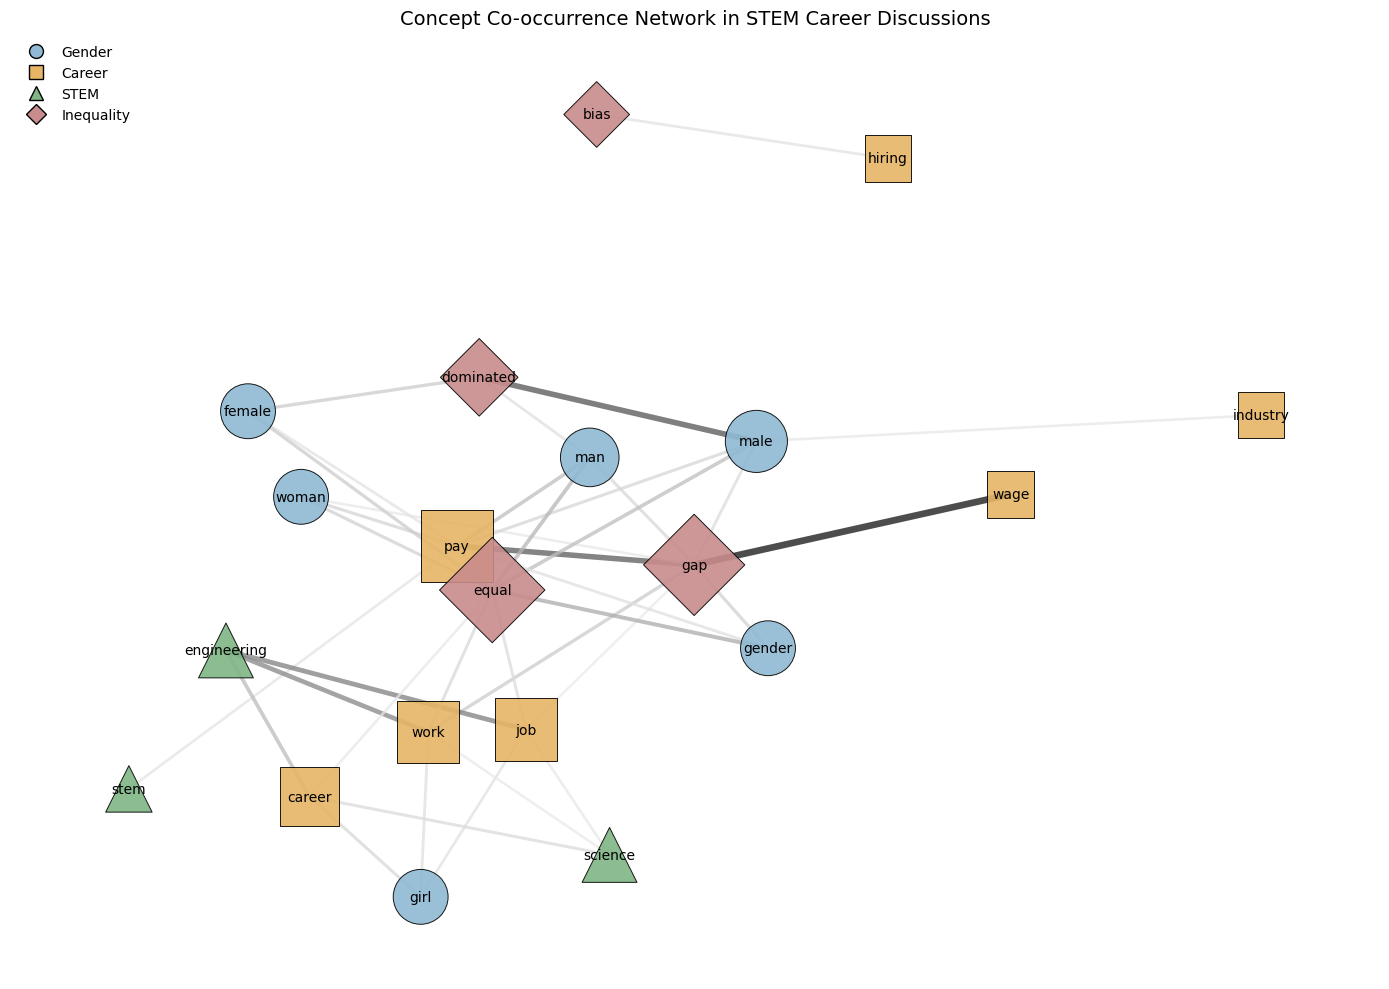

In [77]:
plt.figure(figsize=(14, 10))

# Layout
pos = nx.spring_layout(
    G_final,
    seed=42,
    k=1.6,
    iterations=200
)

# Category settings
group_style = {
    "gender": {
        "shape": "o",
        "color": "#8FB9D4",
        "label": "Gender"
    },
    "career": {
        "shape": "s",
        "color": "#E6B566",
        "label": "Career"
    },
    "stem": {
        "shape": "^",
        "color": "#7FB685",
        "label": "STEM"
    },
    "inequality": {
        "shape": "D",
        "color": "#C98C8C",
        "label": "Inequality"
    }
}

# Draw nodes
for group, style in group_style.items():

    nodes = [
        node for node in G_final.nodes()
        if node_groups_final[node] == group
    ]

    if not nodes:
        continue

    node_sizes = [
        900 + degree_final[node] * 220
        for node in nodes
    ]

    nx.draw_networkx_nodes(
        G_final,
        pos,
        nodelist=nodes,
        node_size=node_sizes,
        node_shape=style["shape"],
        node_color=style["color"],
        edgecolors="black",
        linewidths=0.7,
        alpha=0.9
    )

# =========================================================
# Edge width + darkness = Jaccard strength
# =========================================================

edge_weights = [
    G_final[u][v]["weight"]
    for u, v in G_final.edges()
]

# Stronger association = thicker edge
edge_widths = [
    weight * 12
    for weight in edge_weights
]

# Stronger association = darker edge
nx.draw_networkx_edges(
    G_final,
    pos,
    width=edge_widths,
    edge_color=edge_weights,
    edge_cmap=plt.cm.Greys,
    edge_vmin=0.10,
    edge_vmax=0.42,
    alpha=0.75
)

# Labels
nx.draw_networkx_labels(
    G_final,
    pos,
    font_size=10
)

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker=style["shape"],
        color="w",
        label=style["label"],
        markerfacecolor=style["color"],
        markeredgecolor="black",
        markersize=10
    )
    for style in group_style.values()
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=False
)

plt.title(
    "Concept Co-occurrence Network in STEM Career Discussions",
    fontsize=14
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    r"F:\ERP_data\RQ3_career_cooccurrence_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    r"F:\ERP_data\RQ3_career_cooccurrence_network.pdf",
    bbox_inches="tight"
)

plt.show()

In [68]:
#contextual validation
equal_texts = df[
    df["concepts_final"].apply(
        lambda x: "equal" in x
    )
].copy()

print("Texts containing equal/equality:", len(equal_texts))

Texts containing equal/equality: 138


In [69]:
equal_sample = equal_texts.sample(
    n=min(20, len(equal_texts)),
    random_state=42
)

for i, text in enumerate(
    equal_sample["text_for_analysis"],
    start=1
):
    print("=" * 100)
    print(f"Text {i}")
    print(text)
    print()

Text 1
&gt; We all go to school and become doctors and nurses

Women disproportionately become nurses more than men. They disproportionately go into social services than men. They disproportionately go into employment services more than men. 

Men disproportionately study math and physics and politics more than women. 

&gt; Many guys don't like sports. Many guys actually do like romance and stuff. Not just me. Many guys do/do not work out, do/do not like reading romance books, do/do not watch the same movies as you.

What's the mental health of these guys that don't vs the guys that do bs those that don't? What proportion of the overall male population do they represent among those that aren't indoctrinated into gender equality vs what proportion of the females do they represent?

I'm not denying their existence. Just that a lot of men have been influenced by gender equality to admit they like things they don't and vice versa. 

Idk. Maybe I'm being ideological here too, but I'm not s